## Import Dependencies

In [ ]:
import pandas as pd

In [19]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import numpy as np
import os, json, cv2, random
import cv2
import matplotlib.pyplot as plt

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog, DatasetCatalog, build_detection_test_loader
from detectron2.structures import BoxMode
from detectron2.evaluation import COCOEvaluator, inference_on_dataset

## Convert own images
I took some screenshots while playing on chess.com and extracted the chessboards


Processing chrome_164120_as.png ...
✅ Best square size: 82, score=0.768
💾 Saved to project/chessboards/chrome_164120_as_cropped.png (656x656)


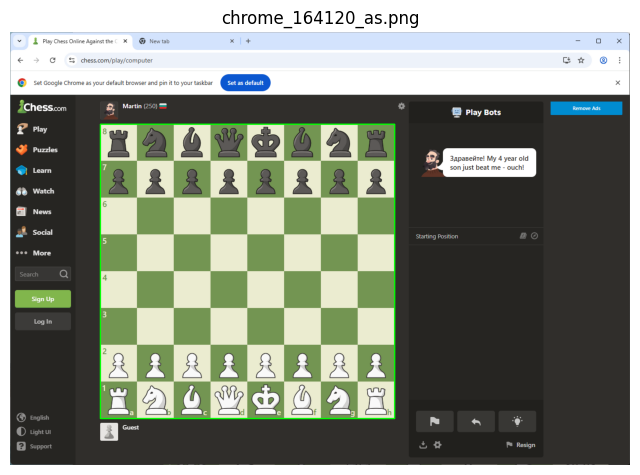


Processing chrome_164150_as.png ...
✅ Best square size: 82, score=0.761
💾 Saved to project/chessboards/chrome_164150_as_cropped.png (656x656)


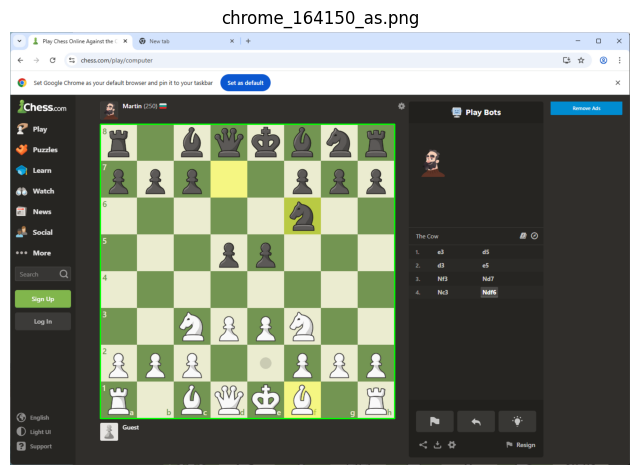


Processing chrome_164220_as.png ...
✅ Best square size: 82, score=0.759
💾 Saved to project/chessboards/chrome_164220_as_cropped.png (656x656)


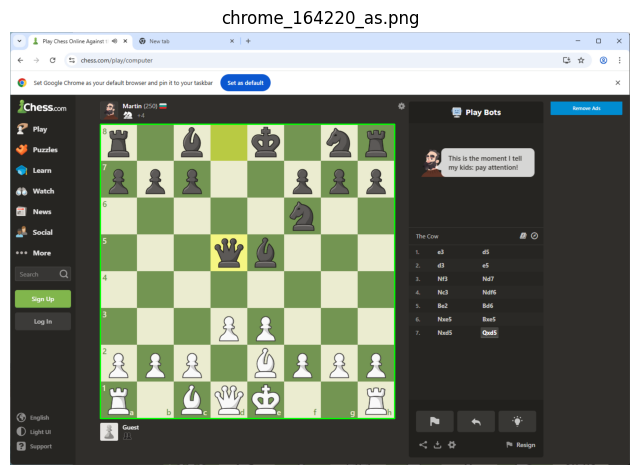


Processing chrome_164250_as.png ...
✅ Best square size: 82, score=0.772
💾 Saved to project/chessboards/chrome_164250_as_cropped.png (656x656)


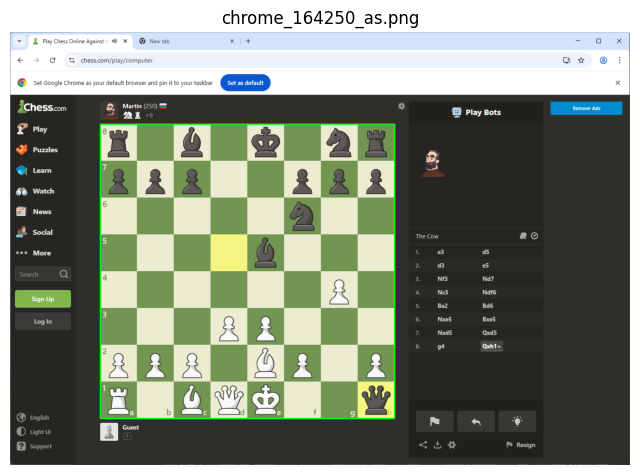


Processing chrome_164320_as.png ...
✅ Best square size: 82, score=0.778
💾 Saved to project/chessboards/chrome_164320_as_cropped.png (656x656)


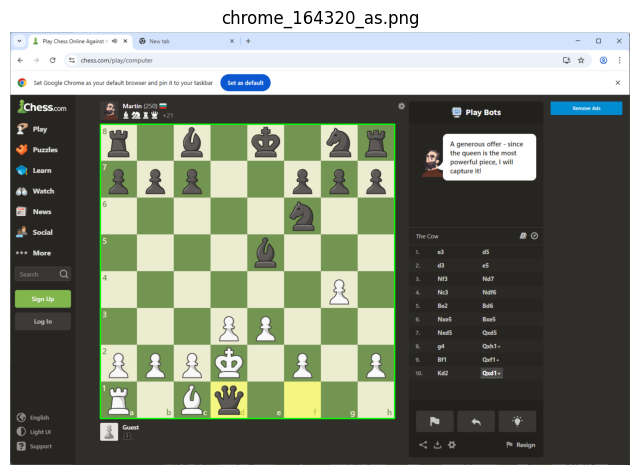


Processing chrome_164350_as.png ...
✅ Best square size: 82, score=0.800
💾 Saved to project/chessboards/chrome_164350_as_cropped.png (656x656)


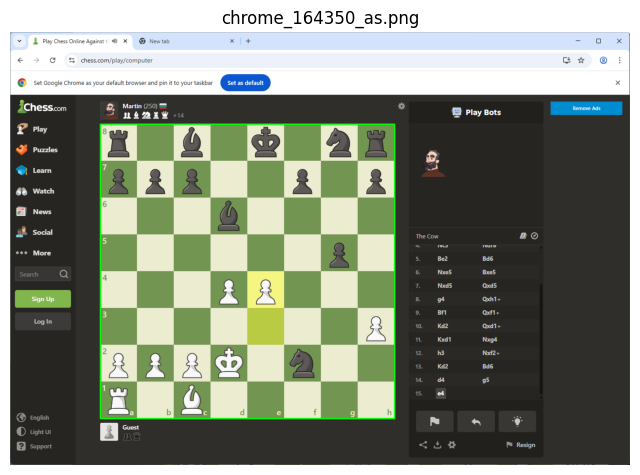


Processing chrome_164420_as.png ...
✅ Best square size: 82, score=0.784
💾 Saved to project/chessboards/chrome_164420_as_cropped.png (656x656)


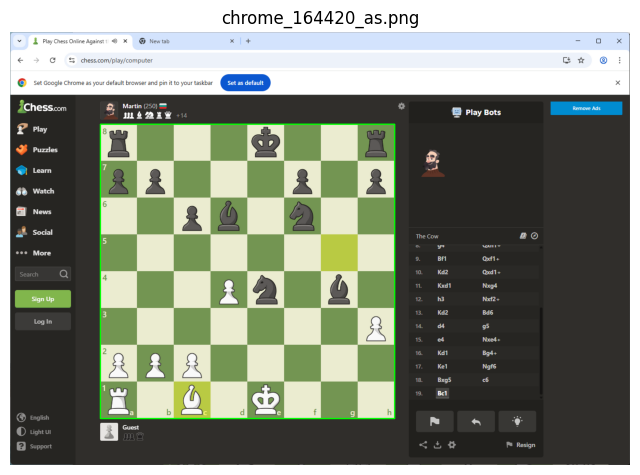


Processing chrome_164450_as.png ...
✅ Best square size: 106, score=0.735
💾 Saved to project/chessboards/chrome_164450_as_cropped.png (848x848)


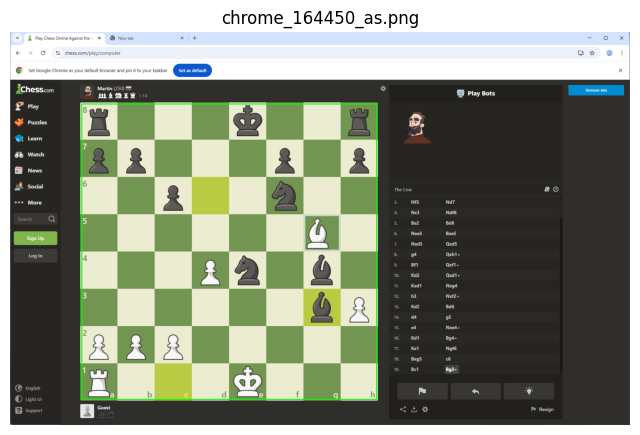


Processing chrome_164520_as.png ...
✅ Best square size: 106, score=0.762
💾 Saved to project/chessboards/chrome_164520_as_cropped.png (848x848)


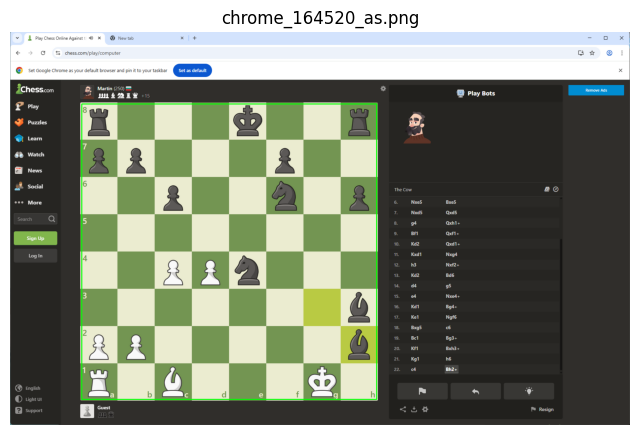


Processing chrome_164550_as.png ...
✅ Best square size: 106, score=0.809
💾 Saved to project/chessboards/chrome_164550_as_cropped.png (848x848)


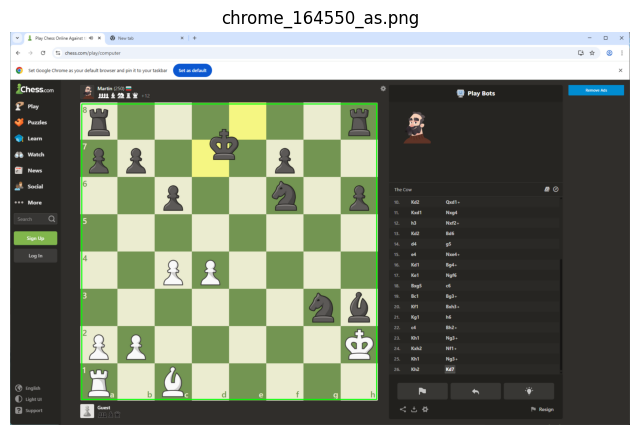


Processing chrome_164620_as.png ...
✅ Best square size: 86, score=0.790
💾 Saved to project/chessboards/chrome_164620_as_cropped.png (688x688)


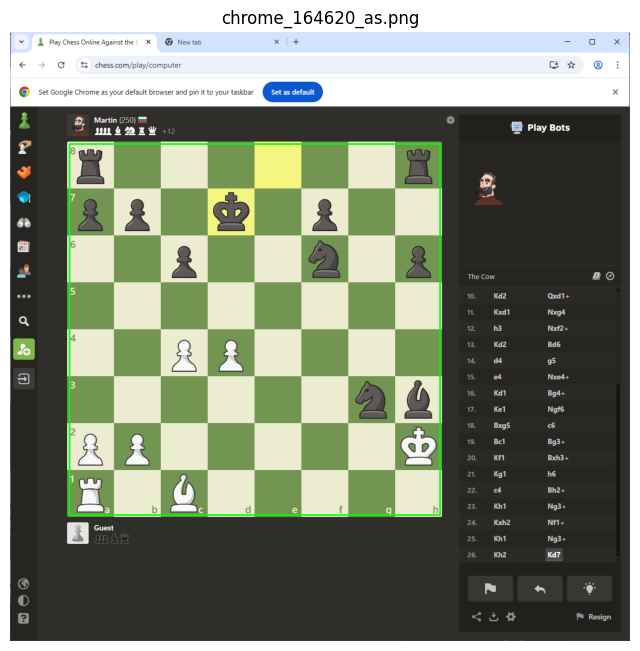


Processing chrome_164650_as.png ...
✅ Best square size: 86, score=0.777
💾 Saved to project/chessboards/chrome_164650_as_cropped.png (688x688)


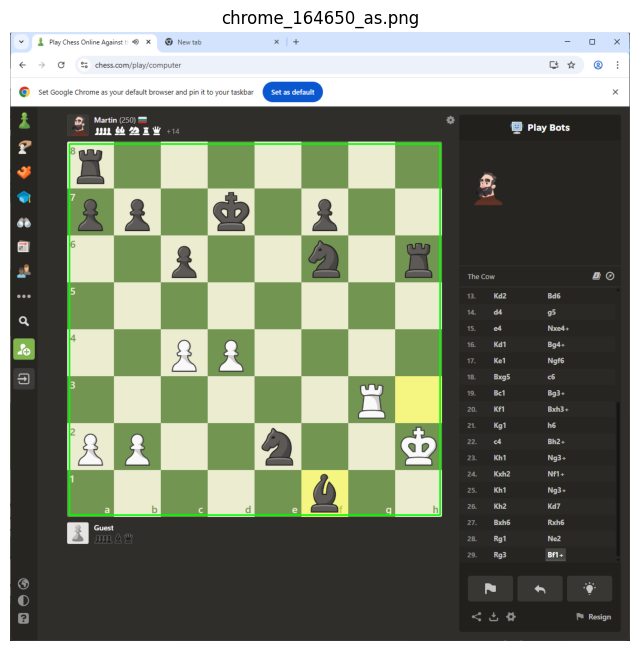


Processing chrome_164720_as.png ...
✅ Best square size: 140, score=0.814
💾 Saved to project/chessboards/chrome_164720_as_cropped.png (1120x1120)


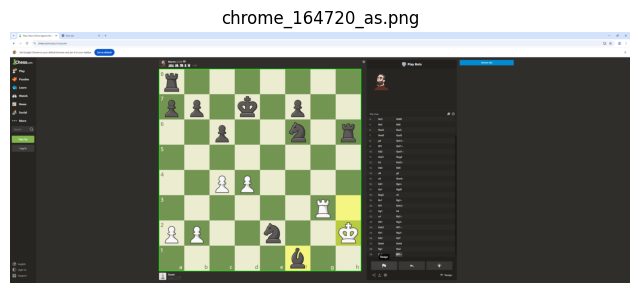


Processing chrome_164750_as.png ...
✅ Best square size: 86, score=0.520
💾 Saved to project/chessboards/chrome_164750_as_cropped.png (688x688)


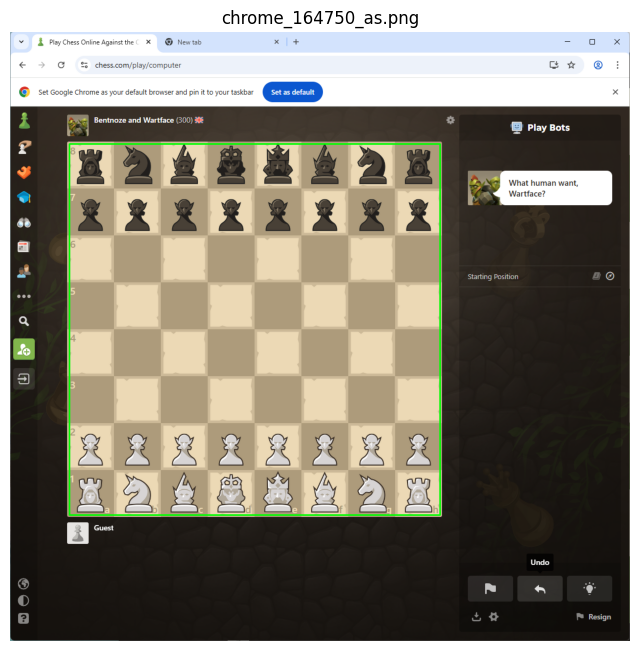


Processing chrome_164820_as.png ...
✅ Best square size: 86, score=0.485
💾 Saved to project/chessboards/chrome_164820_as_cropped.png (688x688)


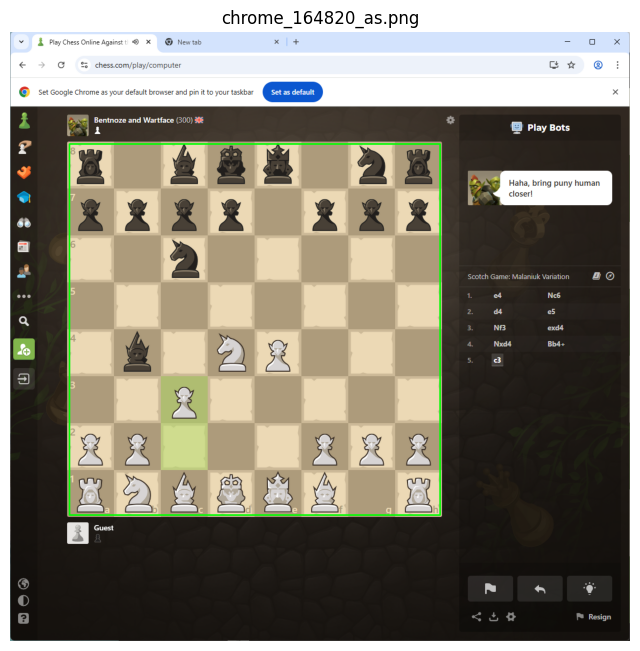


Processing chrome_164850_as.png ...
✅ Best square size: 86, score=0.483
💾 Saved to project/chessboards/chrome_164850_as_cropped.png (688x688)


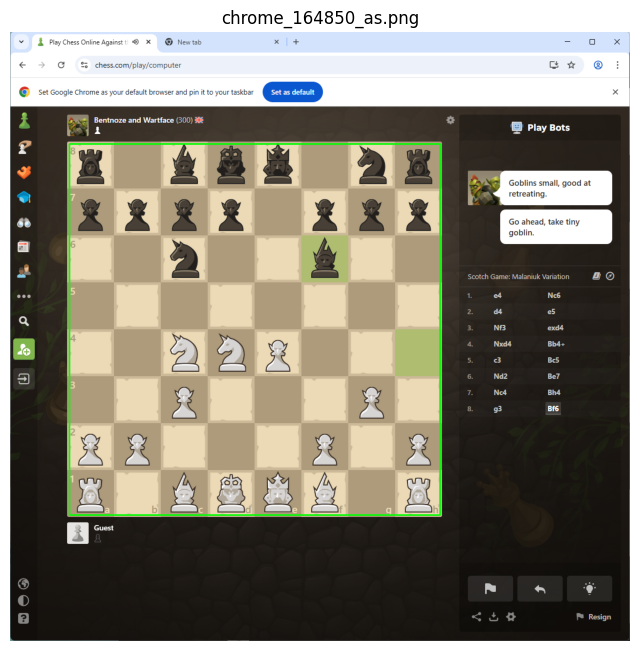


Processing chrome_164920_as.png ...
✅ Best square size: 86, score=0.503
💾 Saved to project/chessboards/chrome_164920_as_cropped.png (688x688)


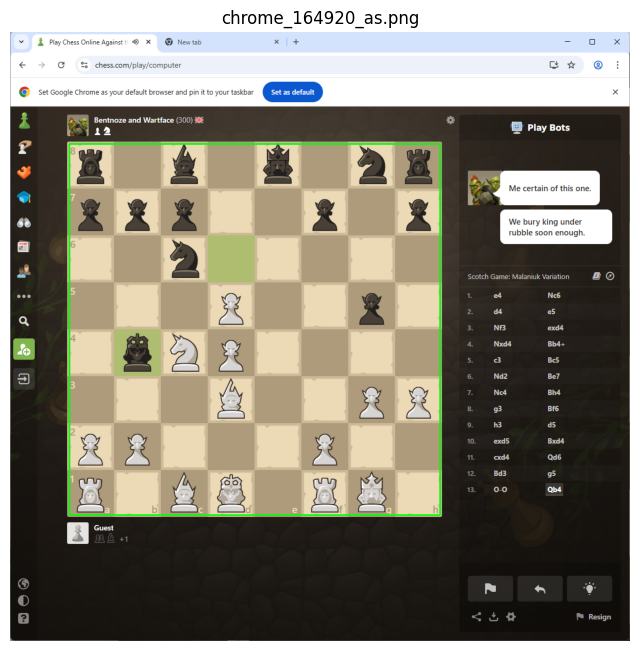


Processing chrome_164950_as.png ...
✅ Best square size: 86, score=0.533
💾 Saved to project/chessboards/chrome_164950_as_cropped.png (688x688)


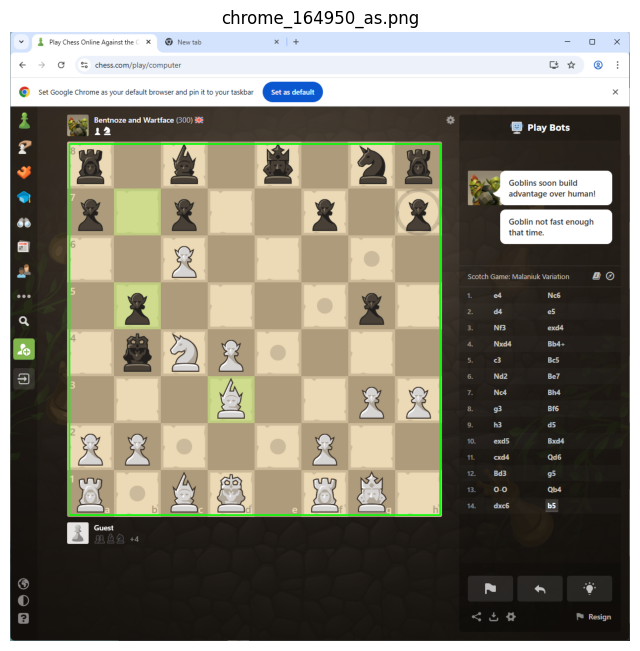


Processing chrome_165050_as.png ...
✅ Best square size: 86, score=0.595
💾 Saved to project/chessboards/chrome_165050_as_cropped.png (688x688)


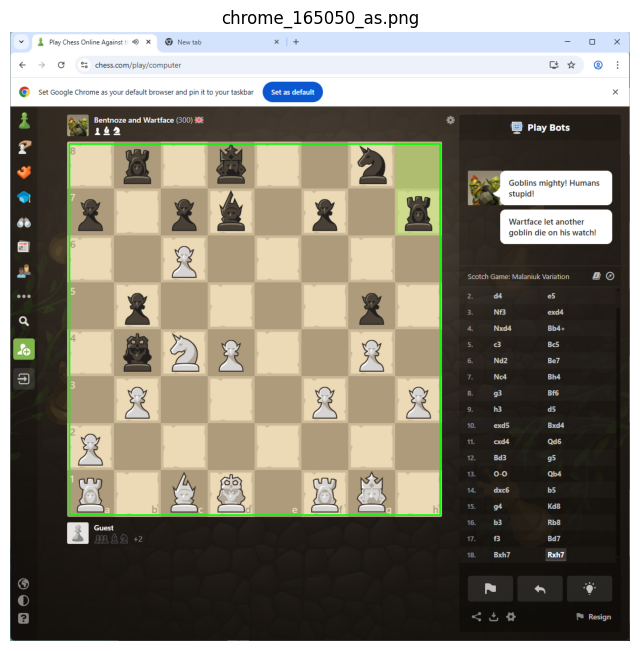


Processing chrome_165150_as.png ...
✅ Best square size: 86, score=0.663
💾 Saved to project/chessboards/chrome_165150_as_cropped.png (688x688)


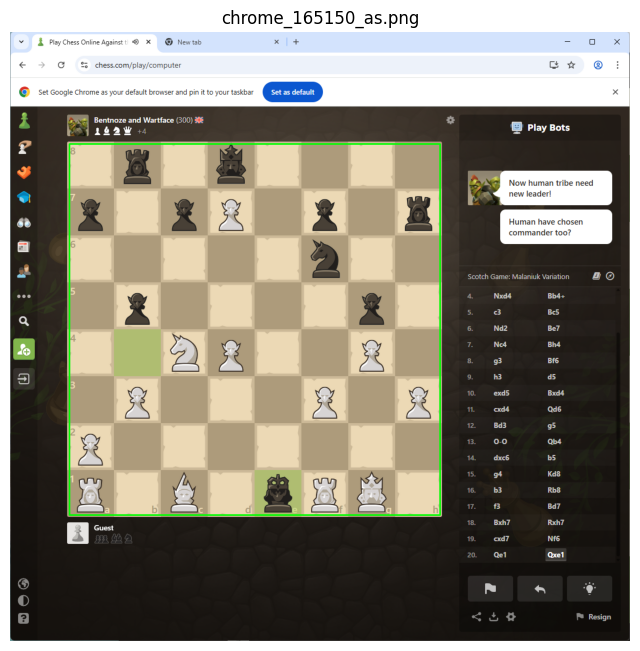


Processing chrome_165220_as.png ...
✅ Best square size: 86, score=0.663
💾 Saved to project/chessboards/chrome_165220_as_cropped.png (688x688)


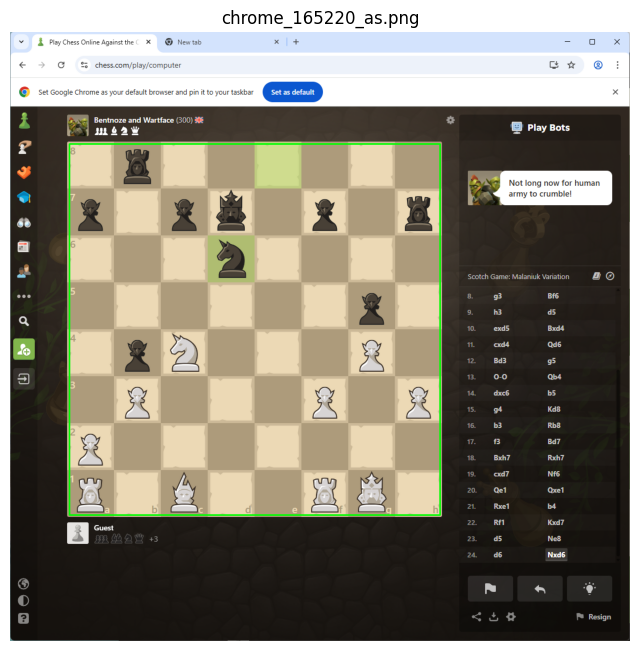


Processing chrome_165250_as.png ...
✅ Best square size: 86, score=0.741
💾 Saved to project/chessboards/chrome_165250_as_cropped.png (688x688)


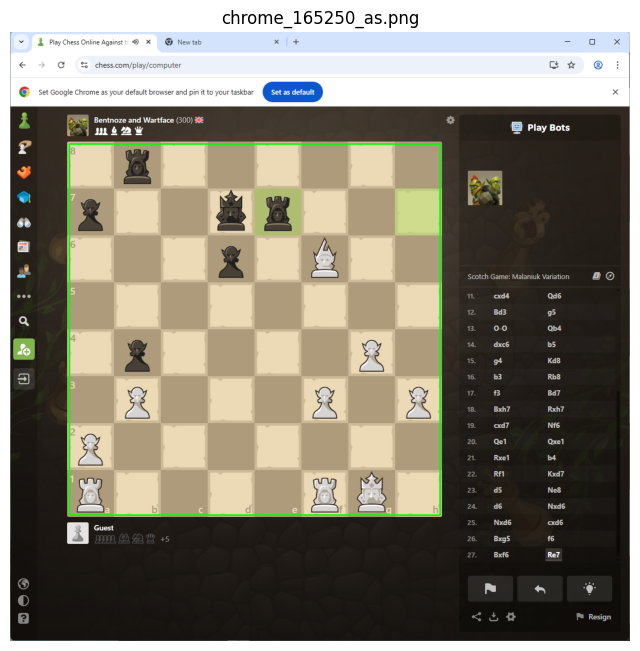


Processing chrome_165320_as.png ...
✅ Best square size: 86, score=0.764
💾 Saved to project/chessboards/chrome_165320_as_cropped.png (688x688)


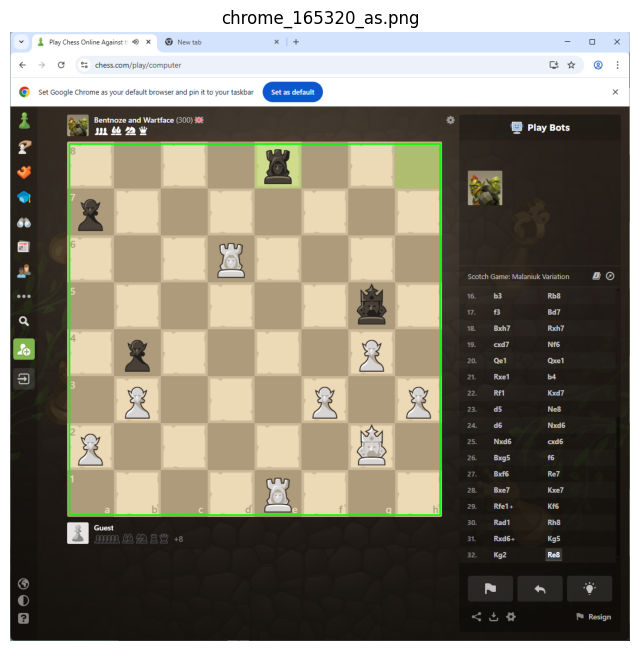


Processing chrome_165350_as.png ...
✅ Best square size: 86, score=0.520
💾 Saved to project/chessboards/chrome_165350_as_cropped.png (688x688)


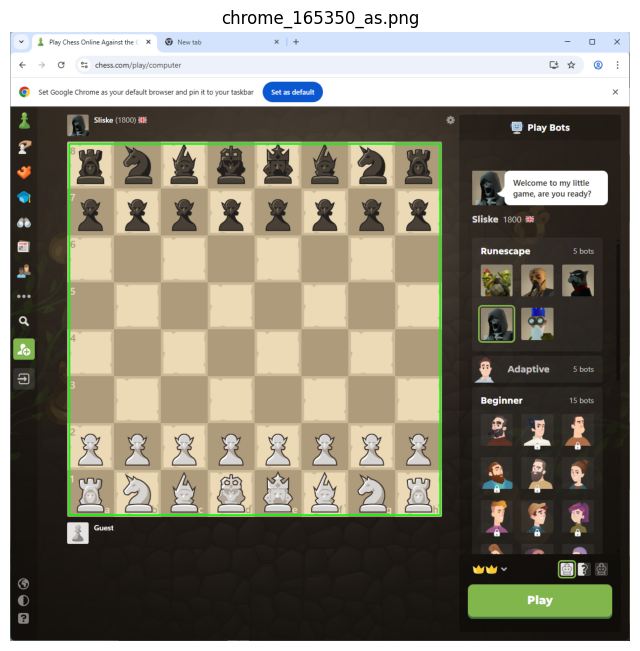


Processing chrome_165420_as.png ...
✅ Best square size: 86, score=0.692
💾 Saved to project/chessboards/chrome_165420_as_cropped.png (688x688)


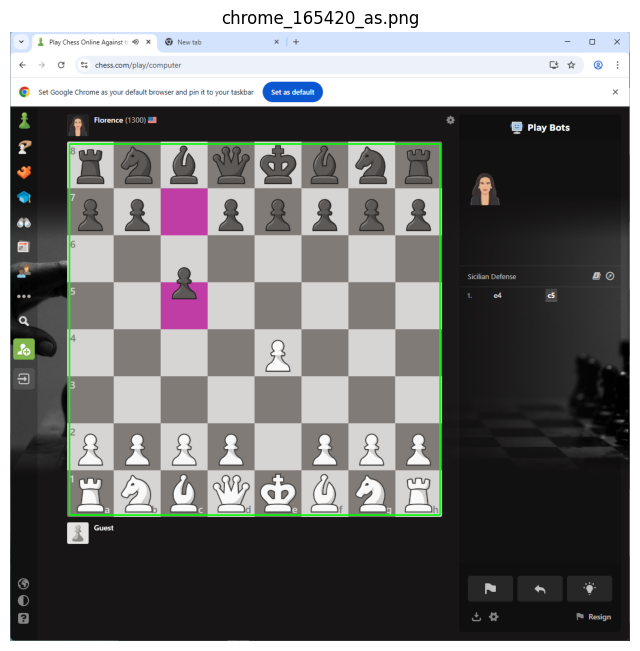


Processing chrome_165450_as.png ...
✅ Best square size: 86, score=0.681
💾 Saved to project/chessboards/chrome_165450_as_cropped.png (688x688)


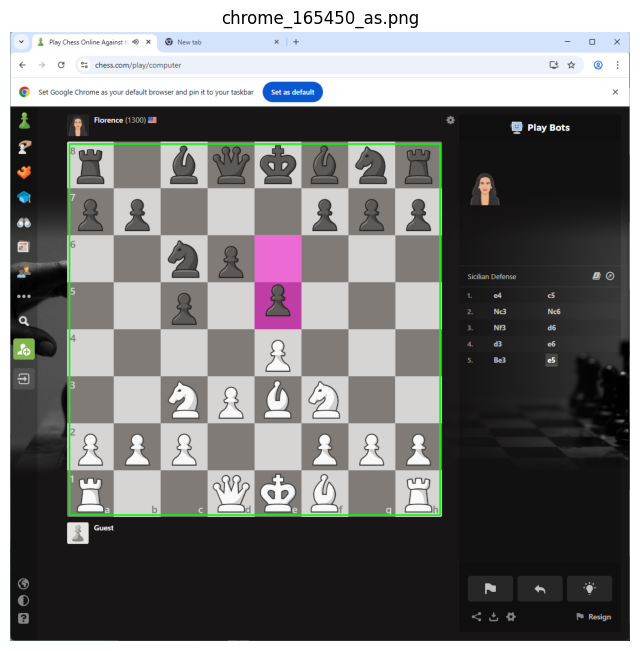


Processing chrome_165520_as.png ...
✅ Best square size: 86, score=0.680
💾 Saved to project/chessboards/chrome_165520_as_cropped.png (688x688)


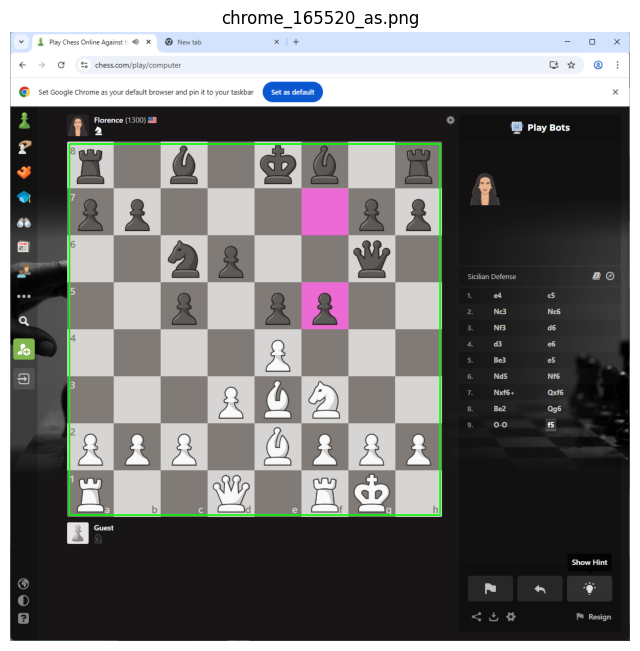


Processing chrome_165550_as.png ...
✅ Best square size: 86, score=0.673
💾 Saved to project/chessboards/chrome_165550_as_cropped.png (688x688)


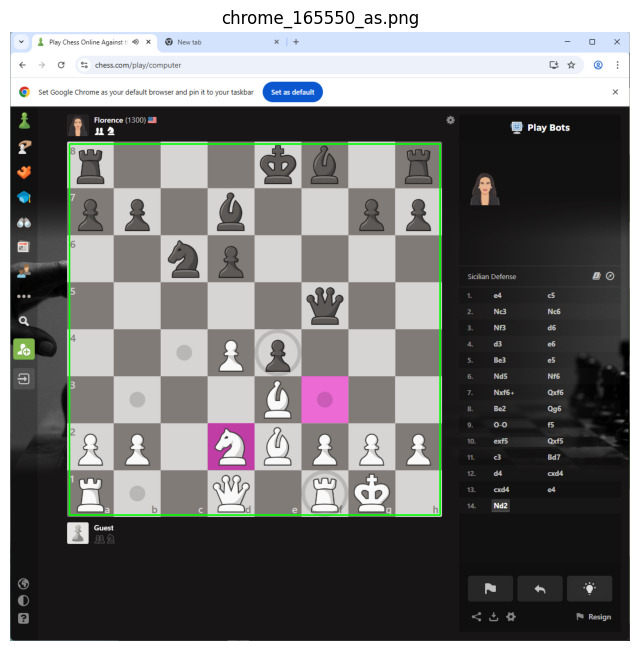


Processing chrome_165620_as.png ...
✅ Best square size: 86, score=0.711
💾 Saved to project/chessboards/chrome_165620_as_cropped.png (688x688)


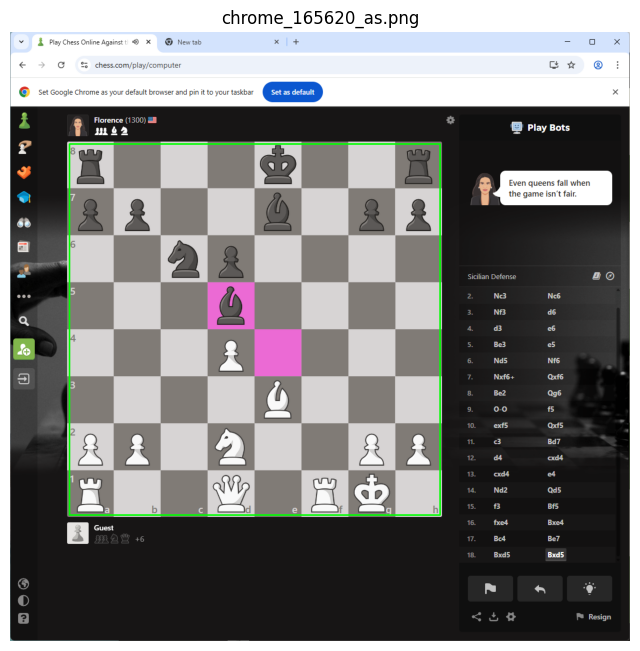


Processing chrome_165650_as.png ...
✅ Best square size: 86, score=0.810
💾 Saved to project/chessboards/chrome_165650_as_cropped.png (688x688)


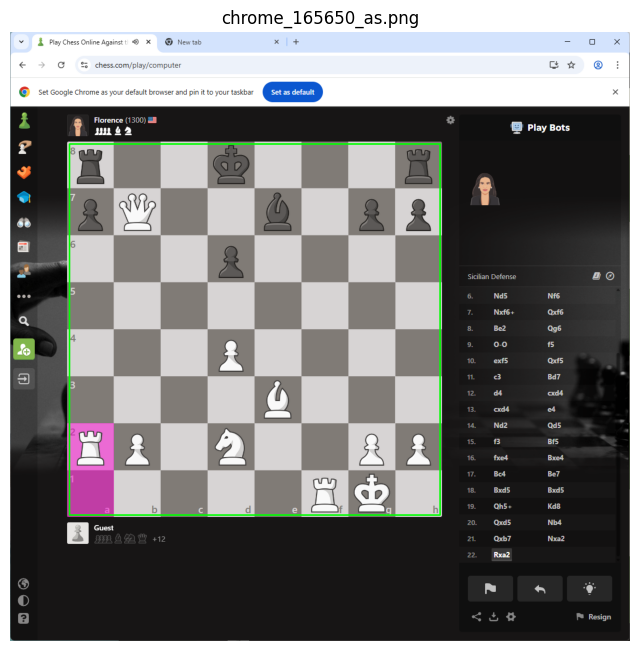


Processing chrome_165720_as.png ...
✅ Best square size: 86, score=0.826
💾 Saved to project/chessboards/chrome_165720_as_cropped.png (688x688)


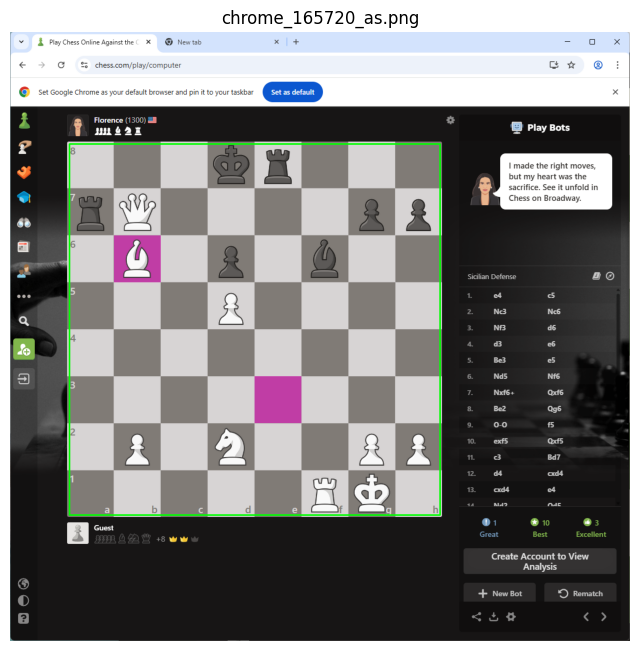


Processing chrome_165750_as.png ...
✅ Best square size: 86, score=0.722
💾 Saved to project/chessboards/chrome_165750_as_cropped.png (688x688)


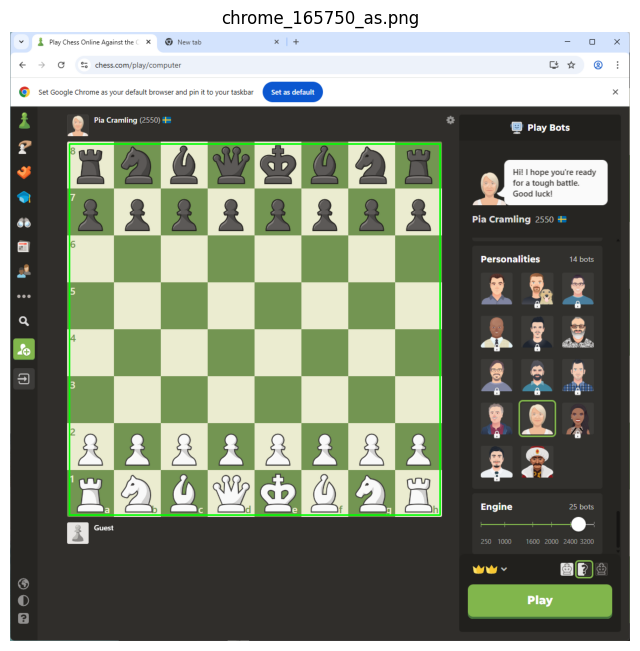


Processing chrome_165820_as.png ...
✅ Best square size: 86, score=0.740
💾 Saved to project/chessboards/chrome_165820_as_cropped.png (688x688)


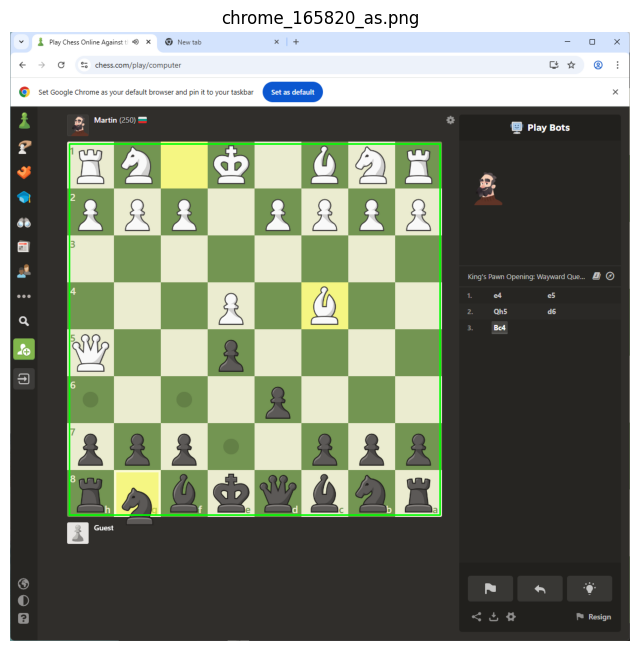


Processing chrome_165850_as.png ...
✅ Best square size: 86, score=0.706
💾 Saved to project/chessboards/chrome_165850_as_cropped.png (688x688)


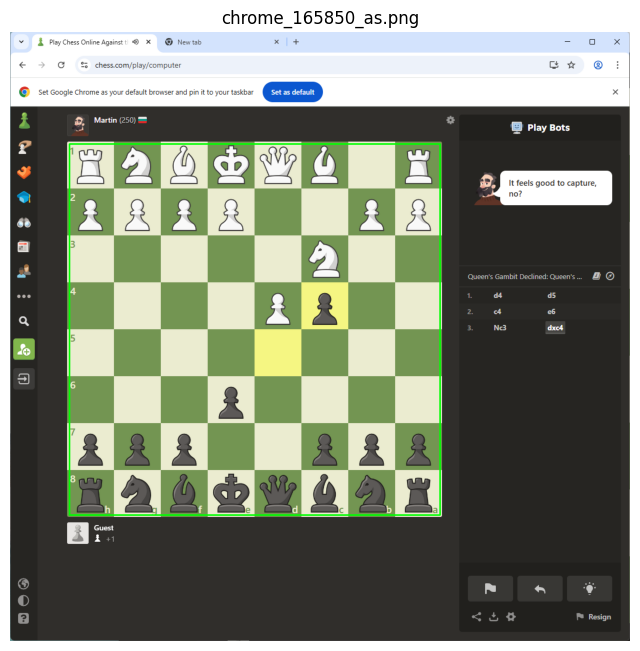


Processing chrome_165920_as.png ...
✅ Best square size: 86, score=0.748
💾 Saved to project/chessboards/chrome_165920_as_cropped.png (688x688)


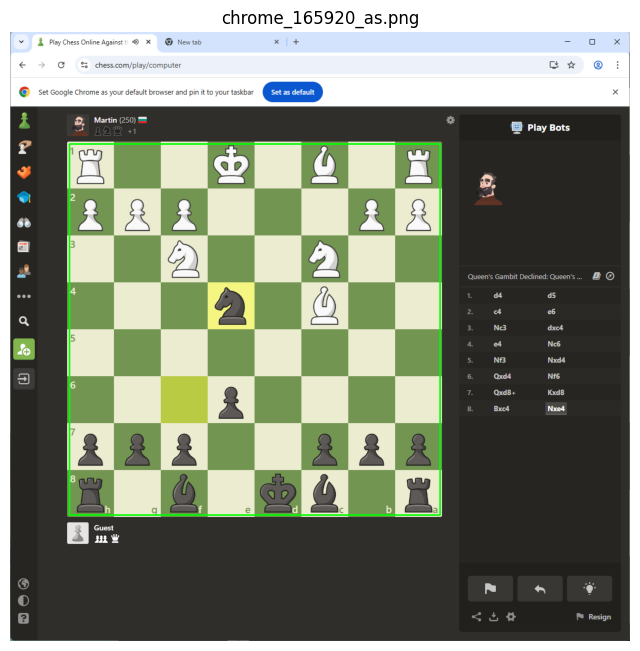


Processing chrome_165950_as.png ...
✅ Best square size: 86, score=0.819
💾 Saved to project/chessboards/chrome_165950_as_cropped.png (688x688)


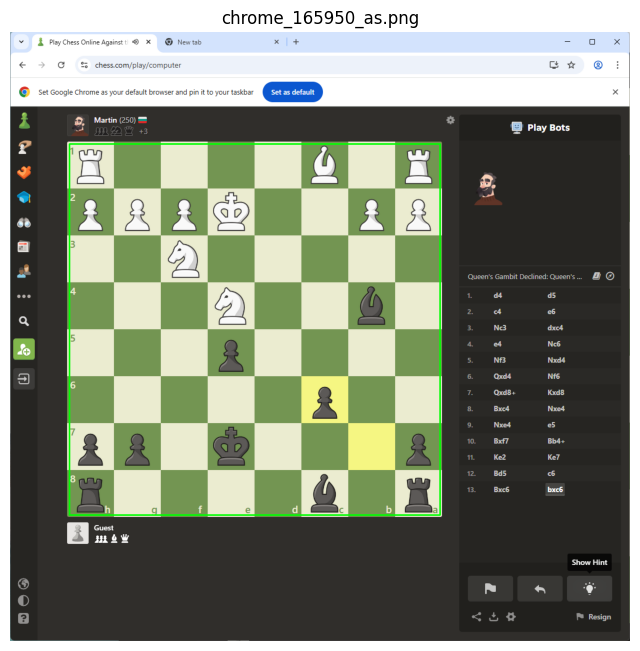


Processing chrome_170020_as.png ...
✅ Best square size: 86, score=0.833
💾 Saved to project/chessboards/chrome_170020_as_cropped.png (688x688)


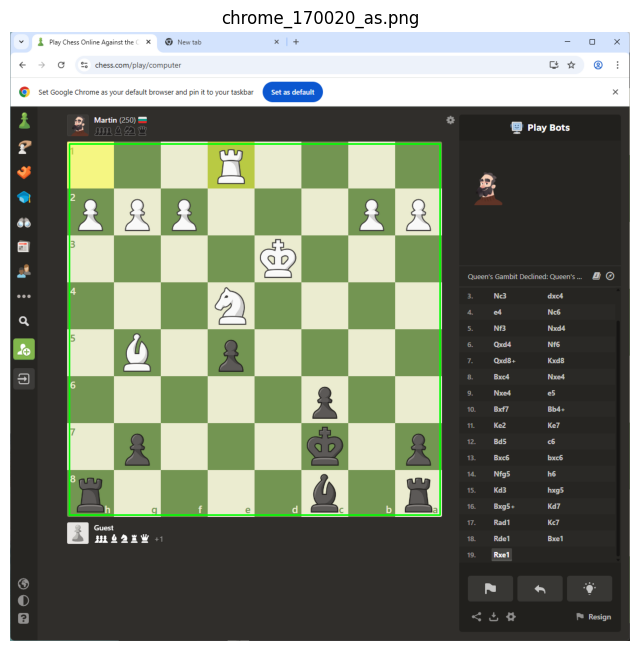


Processing chrome_170050_as.png ...
✅ Best square size: 86, score=0.860
💾 Saved to project/chessboards/chrome_170050_as_cropped.png (688x688)


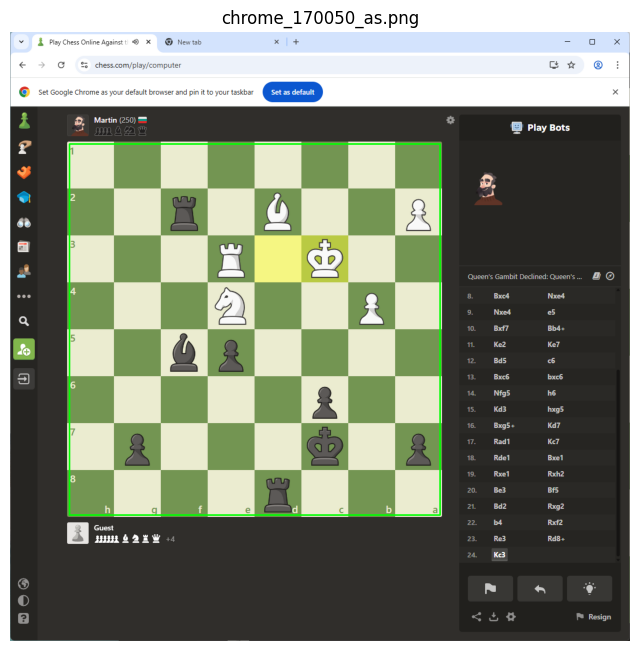


Processing chrome_170120_as.png ...
✅ Best square size: 86, score=0.889
💾 Saved to project/chessboards/chrome_170120_as_cropped.png (688x688)


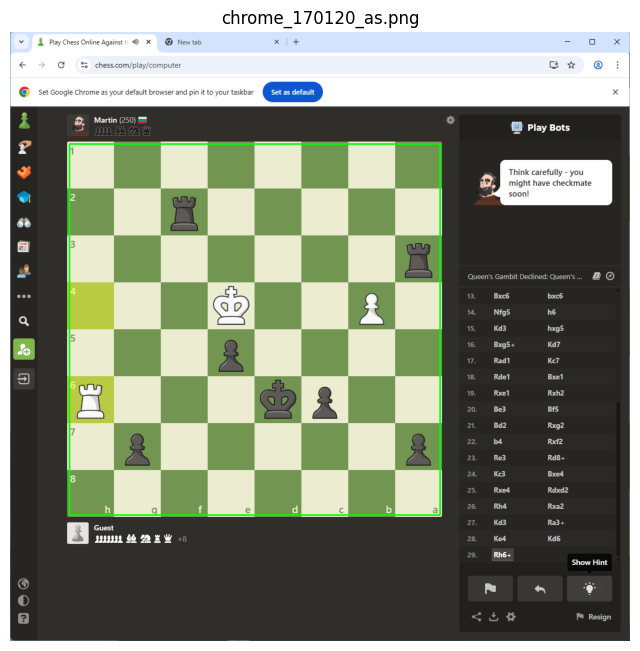


Processing firefox_163920_as.png ...
✅ Best square size: 128, score=0.730
💾 Saved to project/chessboards/firefox_163920_as_cropped.png (1024x1024)


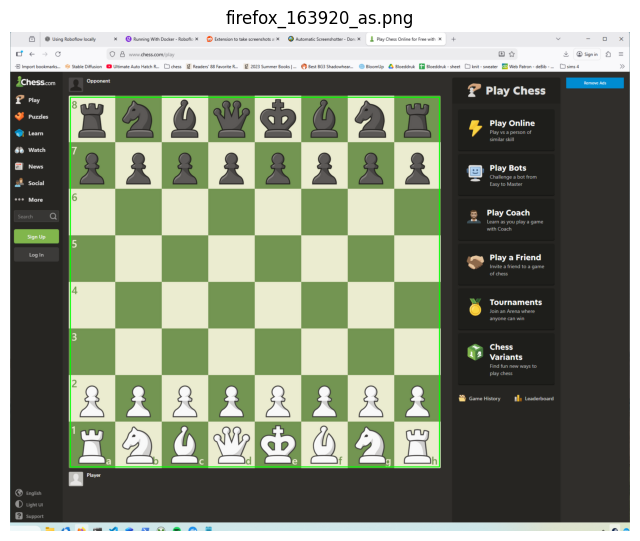

In [2]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# --- input/output folders ---
in_dir = Path("project/browserscreenshots")
out_dir = Path("project/chessboards")
out_dir.mkdir(parents=True, exist_ok=True)

# --- helper: template builder ---
def build_checker_template(square_px: int) -> np.ndarray:
    pattern = (np.indices((8, 8)).sum(axis=0) % 2).astype(np.uint8)  # 0/1
    return (np.kron(pattern, np.ones((square_px, square_px), np.uint8)) * 255)

# --- process each image ---
for img_path in sorted(in_dir.glob("*.png")):
    print(f"\nProcessing {img_path.name} ...")

    img = cv2.imread(str(img_path))
    if img is None:
        print(f"⚠️ Cannot read {img_path}, skipping.")
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    H, W = gray.shape[:2]

    # Candidate square sizes (you can tweak if needed)
    min_sq = 70
    max_sq = 150
    candidates = range(min_sq, max_sq + 1, 2)

    best = {"score": -1, "loc": None, "tmpl": None, "square": None}
    for s in candidates:
        T = build_checker_template(s)
        T_inv = 255 - T  # match both polarities
        for tmpl in (T, T_inv):
            th, tw = tmpl.shape[:2]
            if th >= H or tw >= W:
                continue
            res = cv2.matchTemplate(gray, tmpl, cv2.TM_CCOEFF_NORMED)
            _, maxVal, _, maxLoc = cv2.minMaxLoc(res)
            if maxVal > best["score"]:
                best.update(score=maxVal, loc=maxLoc, tmpl=tmpl, square=s)

    if best["loc"] is None:
        print("❌ Could not locate the chessboard.")
        continue

    print(f"✅ Best square size: {best['square']}, score={best['score']:.3f}")

    # --- crop result ---
    x0, y0 = best["loc"]
    bh, bw = best["tmpl"].shape[:2]
    crop = img[y0:y0 + bh, x0:x0 + bw]

    # Save result
    out_path = out_dir / f"{img_path.stem}_cropped.png"
    cv2.imwrite(str(out_path), crop)
    print(f"💾 Saved to {out_path} ({crop.shape[1]}x{crop.shape[0]})")

    # --- optional debug ---
    img_debug = img.copy()
    cv2.rectangle(img_debug, (x0, y0), (x0 + bw, y0 + bh), (0, 255, 0), 2)
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img_debug, cv2.COLOR_BGR2RGB))
    plt.title(img_path.name)
    plt.axis("off")
    plt.show()

## Load model
I found a few models on chess.com images on [roboflow](https://universe.roboflow.com). 
I also looked on huggingface: I did find a model there that used chess pieces: https://huggingface.co/NAKSTStudio/yolov8m-chess-piece-detection, it was not specific for chess.com, but it might work. To be tested, could be especially interesting to detect chess pieces from different websites.

I selected the model with the highest precision and recall: https://universe.roboflow.com/grupo-12/grupo12-fzbt4 . I couldn't find a way to use this model locally. It was possible to download the dataset in COCO format, I stored these images in data/Grupo12. The category_ids in this COCO format were not formatted correctly, which explains the complicated code to load the dataset :)


In [13]:
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import load_coco_json

# 0) Define mapping: skip id 0 ("Chess-pieces") and shift everything down by one
id_map = {1:0, 2:1, 3:2, 4:3, 5:4, 6:5, 7:6, 8:7, 9:8, 10:9, 11:10, 12:11}

thing_classes = [
    "black_bishop","black_king","black_knight","black_pawn","black_queen","black_rook",
    "white_bishop","white_king","white_knight","white_pawn","white_queen","white_rook"
]

def load_and_remap(json_file, image_root):
    # IMPORTANT: dataset_name=None so load_coco_json does NOT set metadata
    dicts = load_coco_json(json_file, image_root, dataset_name=None)
    fixed = []
    skipped = 0

    for d in dicts:
        anns = []
        for ann in d.get("annotations", []):
            old = ann["category_id"]
            if old == 0:
                # supercategory "Chess-pieces" — drop if it appears by mistake
                skipped += 1
                continue
            if old not in id_map:
                raise ValueError(f"Unknown category_id {old}; expected 1..12")
            ann = dict(ann)  # shallow copy
            ann["category_id"] = id_map[old]
            anns.append(ann)

        dd = dict(d)
        dd["annotations"] = anns
        fixed.append(dd)

    if skipped:
        print(f"⚠️ Skipped {skipped} annotation(s) with category_id=0 (supercategory)")

    return fixed

def register_fixed(name, json_file, image_root):
    data = load_and_remap(json_file, image_root)  # load once, keep stable
    DatasetCatalog.register(name, lambda d=data: d)
    MetadataCatalog.get(name).set(thing_classes=thing_classes)

# 1) Register NEW names to avoid clashes with previous registrations
register_fixed("chess_train", "data/Grupo12/train/_annotations.coco.json", "data/Grupo12/train")
register_fixed("chess_valid", "data/Grupo12/valid/_annotations.coco.json", "data/Grupo12/valid")
register_fixed("chess_test",  "data/Grupo12/test/_annotations.coco.json",  "data/Grupo12/test")

print("✅ Registered chess_* with remapped labels (0..11).")

# 2) Sanity check
for n in ["chess_train", "chess_valid", "chess_test"]:
    ds = DatasetCatalog.get(n)
    labels = sorted({a["category_id"] for d in ds for a in d.get("annotations", [])})
    print(n, labels)  # should print [0,1,2,...,11]


[11/15 07:26:34 d2.data.datasets.coco]: Loaded 407 images in COCO format from data/Grupo12/train/_annotations.coco.json
[11/15 07:26:34 d2.data.datasets.coco]: Loaded 117 images in COCO format from data/Grupo12/valid/_annotations.coco.json
[11/15 07:26:34 d2.data.datasets.coco]: Loaded 62 images in COCO format from data/Grupo12/test/_annotations.coco.json
✅ Registered chess_* with remapped labels (0..11).
chess_train [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
chess_valid [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
chess_test [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [ ]:
# from detectron2.data import DatasetCatalog, MetadataCatalog

# DatasetCatalog.remove("chess_train")
# MetadataCatalog.remove("chess_train")
# DatasetCatalog.remove("chess_test")
# MetadataCatalog.remove("chess_test")
# DatasetCatalog.remove("chess_valid")
# MetadataCatalog.remove("chess_valid")

In [6]:
from detectron2.data import MetadataCatalog, DatasetCatalog

print(len(DatasetCatalog.get("chess_train")))
print(len(DatasetCatalog.get("chess_test")))
print(len(DatasetCatalog.get("chess_valid")))


407
62
117


Print a few annotated examples from the train dataset.

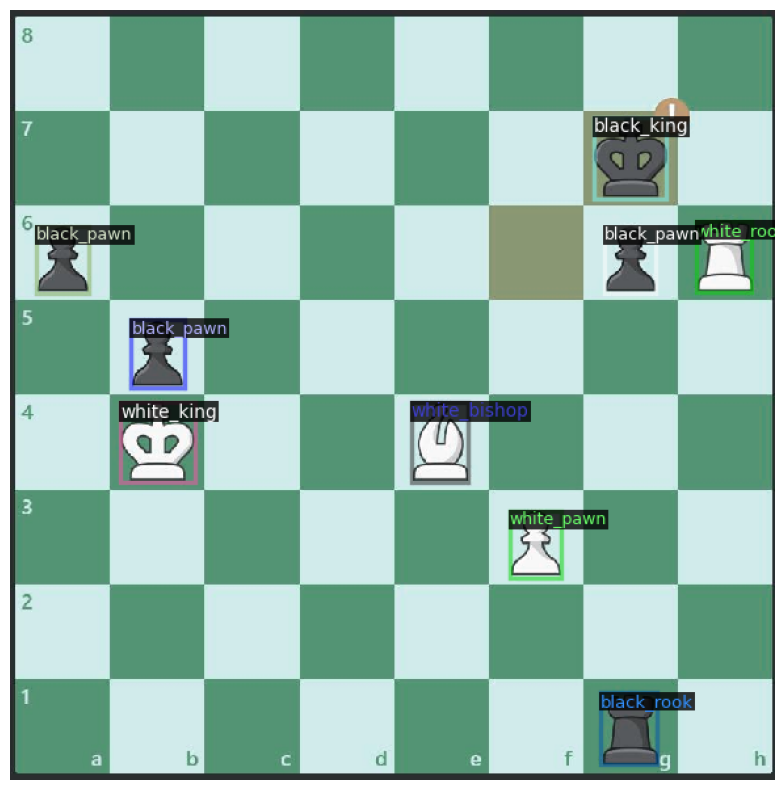

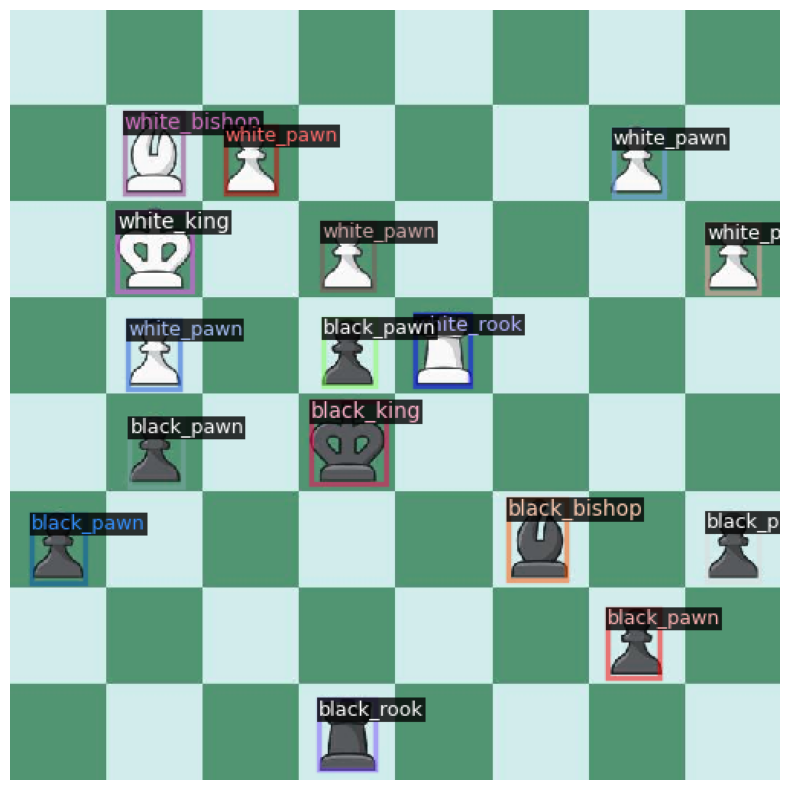

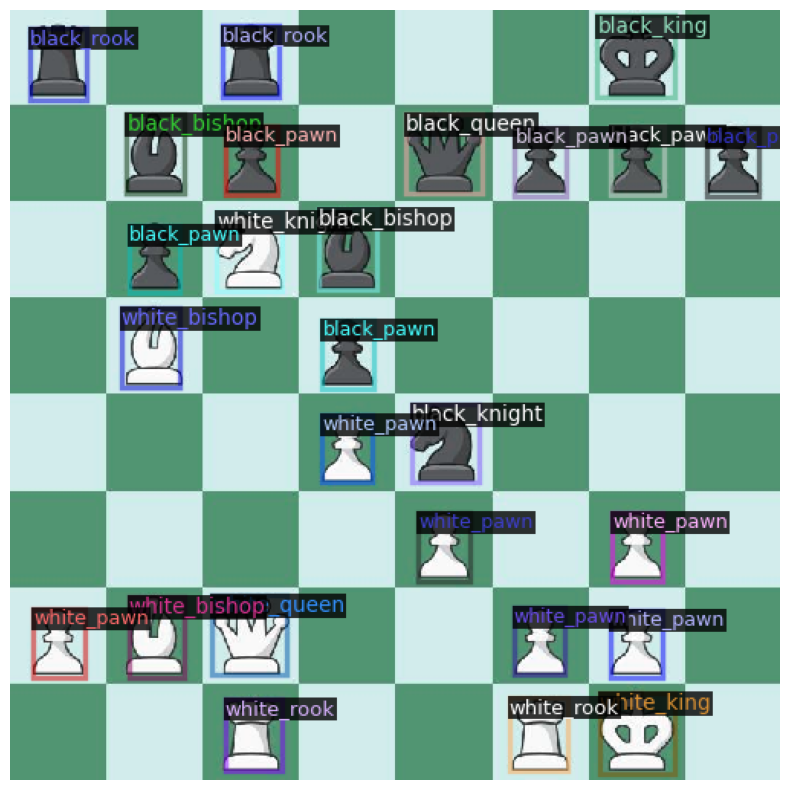

In [7]:
dataset_dicts = DatasetCatalog.get("chess_train")
dataset_with_anns = [d for d in dataset_dicts if len(d.get("annotations", [])) > 0]
chicken_metadata = MetadataCatalog.get("chess_train")

for d in random.sample(dataset_with_anns, 3):
    img = cv2.imread(d["file_name"])  # BGR
    v = Visualizer(img[:, :, ::-1], metadata=chicken_metadata, scale=0.7)  # RGB
    out = v.draw_dataset_dict(d)

    plt.figure(figsize=(10, 10))
    plt.imshow(out.get_image()[:, :, ::-1])  # back to RGB for matplotlib
    plt.axis("off")
    plt.show()

Create the config for the trainer. Put this in a separate cell because this config is also used for loading the model.

In [14]:

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")) #select config from model zoo
cfg.DATASETS.TRAIN = ("chess_train",)
cfg.DATASETS.TEST = ("chess_test",)
cfg.DATALOADER.NUM_WORKERS = 2
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")  #select model from model zoo
cfg.SOLVER.IMS_PER_BATCH = 2  # batch size
cfg.SOLVER.BASE_LR = 0.01  # learning rate
cfg.SOLVER.MAX_ITER = 5000    # 300 iterations seems good enough for this toy dataset; you will need to train longer for a practical dataset
cfg.SOLVER.STEPS = [2000, 3500]        # reduce learning rate at these iterations
cfg.SOLVER.GAMMA = 0.01 # reduce learning rate by a factor of 0.1
cfg.OUTPUT_DIR = "./output"
cfg.TEST.EVAL_PERIOD = 100  # evaluate every 100 iterations
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size". 128 is faster, and good enough for this toy dataset (default: 512)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 12 

In [ ]:
from detectron2.engine import DefaultTrainer


os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()

[11/14 20:21:34 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

model_final_280758.pkl: 167MB [00:15, 11.1MB/s]                                                                         
Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (13, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (13,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (48, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (48,) in the model! You might want to double check if this is expected.
Some model parameters or buffers 

[11/14 20:21:50 d2.engine.train_loop]: Starting training from iteration 0
[11/14 20:21:52 d2.utils.events]:  eta: 0:09:20  iter: 19  total_loss: 3.06  loss_cls: 2.222  loss_box_reg: 0.8158  loss_rpn_cls: 0.02432  loss_rpn_loc: 0.04215  time: 0.1115  data_time: 0.0091  lr: 0.00019981  max_mem: 2971M
[11/14 20:21:55 d2.utils.events]:  eta: 0:09:28  iter: 39  total_loss: 1.861  loss_cls: 0.9857  loss_box_reg: 0.8264  loss_rpn_cls: 0.002844  loss_rpn_loc: 0.03667  time: 0.1150  data_time: 0.0041  lr: 0.00039961  max_mem: 2971M
[11/14 20:21:57 d2.utils.events]:  eta: 0:09:26  iter: 59  total_loss: 1.503  loss_cls: 0.7075  loss_box_reg: 0.7341  loss_rpn_cls: 0.002119  loss_rpn_loc: 0.02825  time: 0.1151  data_time: 0.0040  lr: 0.00059941  max_mem: 2971M
[11/14 20:21:59 d2.utils.events]:  eta: 0:09:22  iter: 79  total_loss: 1.258  loss_cls: 0.5789  loss_box_reg: 0.643  loss_rpn_cls: 0.0004651  loss_rpn_loc: 0.03258  time: 0.1143  data_time: 0.0042  lr: 0.00079921  max_mem: 2971M
[11/14 20:22:

In [9]:
# Inference should use the config with parameters that are used in training
# cfg now already contains everything we've set previously. We changed it a little bit for inference:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

In [10]:
chess_metadata = MetadataCatalog.get("chess_valid")

Test the trained model on a few images from the validation dataset

/usr/local/lib/python3.8/dist-packages/torch/_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  /pytorch/aten/src/ATen/native/BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
/usr/local/lib/python3.8/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /pytorch/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


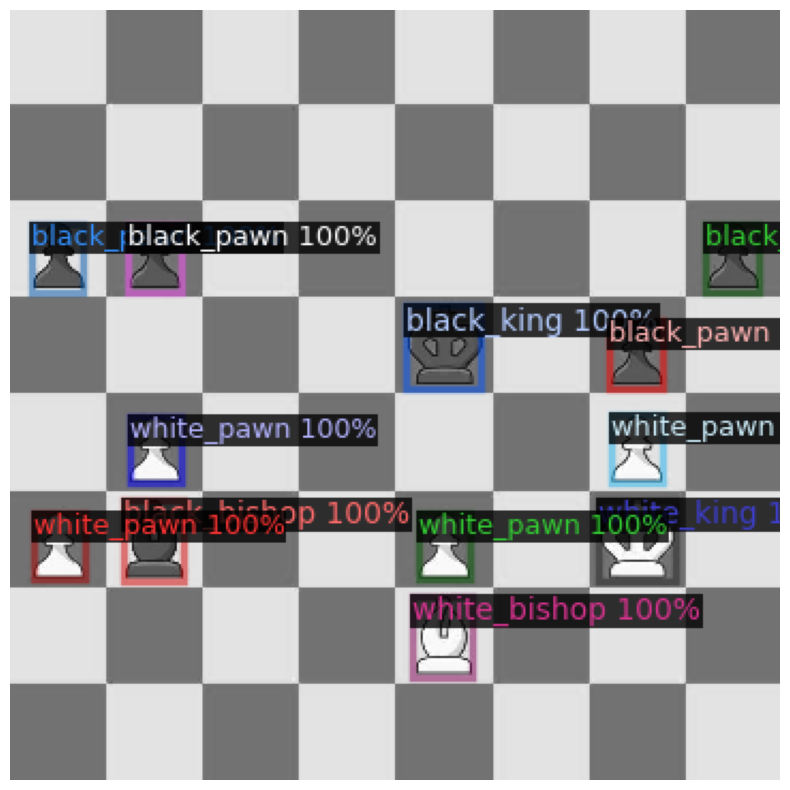

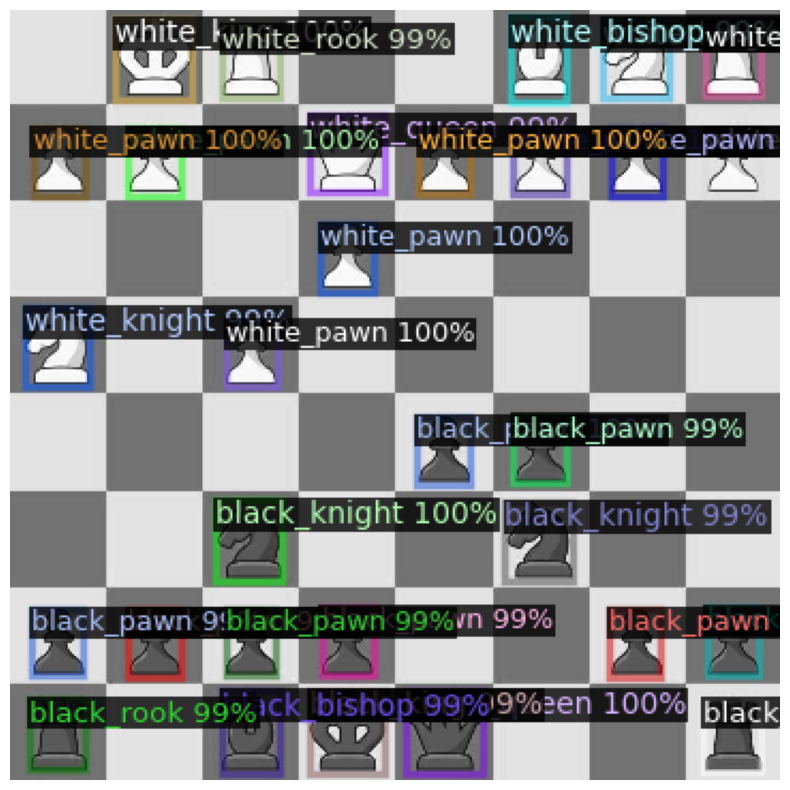

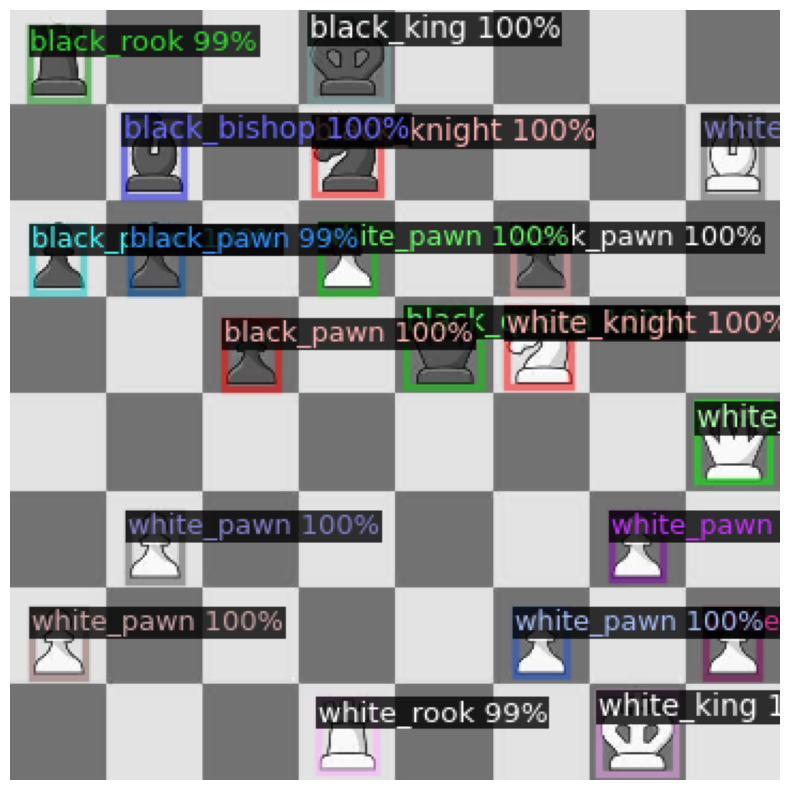

In [15]:
dataset_dicts  = DatasetCatalog.get("chess_valid")
for d in random.sample(dataset_dicts, 3):    
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
    v = Visualizer(im[:, :, ::-1],
                   metadata=chess_metadata, 
                   scale=0.5, 
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of unsegmented pixels. This option is only available for segmentation models
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    plt.figure(figsize=(10,10))
    plt.imshow(out.get_image()[:, :, ::-1])
    plt.axis('off')

Test the trained model on an image created by ourselves.

(-0.5, 359.5, 359.5, -0.5)

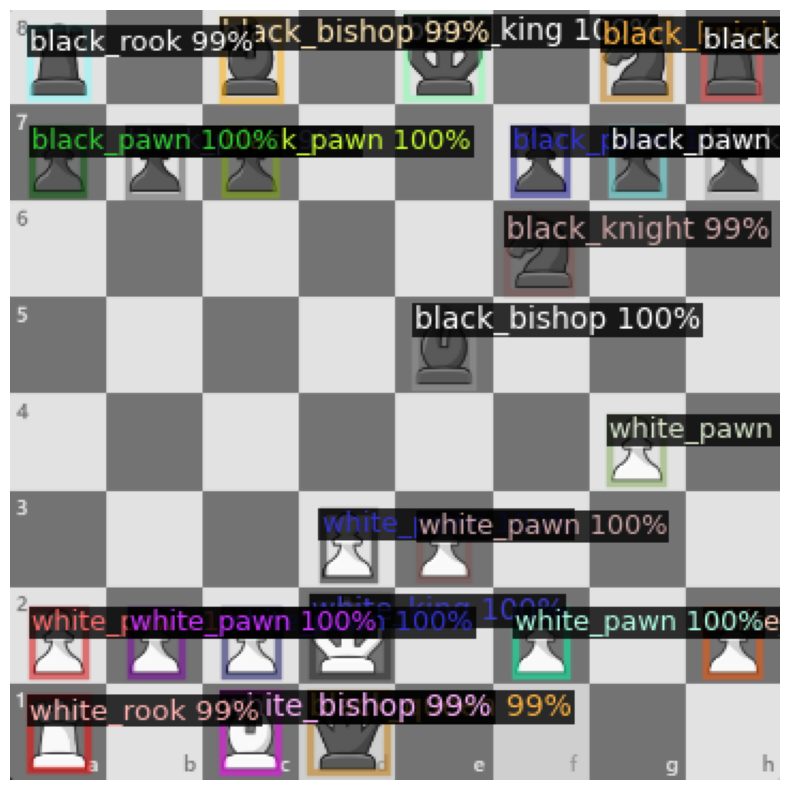

In [25]:
img = cv2.imread("data/chessboards/chrome_164320_as_cropped.png")
img = cv2.resize(img, (720, 720))  # resize to same size as training images
outputs = predictor(img)
v = Visualizer(img[:, :, ::-1],
                   metadata=chess_metadata, 
                   scale=0.5, 
                   instance_mode=ColorMode.IMAGE_BW   # remove the colors of aunsegmented pixels. This option is only available for segmentation models
    )
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(10,10))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis('off')

In [26]:
outputs

{'instances': Instances(num_instances=25, image_height=720, image_width=720, fields=[pred_boxes: Boxes(tensor([[111.3344, 559.8394, 159.2874, 621.8900],
         [ 20.2676, 559.2763,  69.6635, 621.9576],
         [381.5971, 469.7380, 428.9282, 532.7720],
         [650.6229, 560.2715, 699.3524, 622.7945],
         [560.8765, 379.1645, 609.5223, 442.6276],
         [369.5615,   5.6598, 439.5672,  82.7441],
         [281.0359, 548.2966, 351.1113, 622.7178],
         [471.2869, 559.5640, 519.6602, 622.3354],
         [ 20.7147, 110.2887,  68.4153, 172.8374],
         [290.9951, 468.5324, 339.4743, 532.1160],
         [378.3359, 275.6359, 432.1136, 352.6655],
         [200.6243, 110.1219, 248.8281, 172.7251],
         [200.8768, 559.1187, 249.4369, 621.8452],
         [470.0341, 109.3342, 519.2309, 172.7109],
         [651.2256, 110.3075, 699.7383, 173.9944],
         [648.0270,  13.7033, 700.9760,  82.3798],
         [110.7288, 110.1648, 159.4889, 173.5763],
         [198.2556,   7.1760, 2

In [27]:
import numpy as np

def get_chess_piece_label(class_id, thing_classes):
    # Map class index to piece symbol (FEN style)
    mapping = {
        "black_king": "k", "black_queen": "q", "black_rook": "r", "black_bishop": "b", "black_knight": "n", "black_pawn": "p",
        "white_king": "K", "white_queen": "Q", "white_rook": "R", "white_bishop": "B", "white_knight": "N", "white_pawn": "P"
    }
    label = thing_classes[class_id]
    return mapping.get(label, "?")

def convert_to_chess_grid(outputs, thing_classes):
    # Assume outputs["instances"] contains .pred_boxes and .pred_classes
    boxes = outputs["instances"].pred_boxes.tensor.cpu().numpy()
    classes = outputs["instances"].pred_classes.cpu().numpy()
    grid = [["." for _ in range(8)] for _ in range(8)]

    # For each detected piece, estimate its grid position
    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = box
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        # Assuming image is 720x720 and board is full image
        col = cx * 8 // 720
        row = cy * 8 // 720
        piece = get_chess_piece_label(cls, thing_classes)
        grid[row][col] = piece

    # Convert grid to text
    return "\n".join(" ".join(row) for row in grid)

# Usage after prediction:
thing_classes = [
    "black_bishop","black_king","black_knight","black_pawn","black_queen","black_rook",
    "white_bishop","white_king","white_knight","white_pawn","white_queen","white_rook"
]
text_grid = convert_to_chess_grid(outputs, thing_classes)
print(text_grid)

r . b . k . n r
p p p . . p p p
. . . . . n . .
. . . . b . . .
. . . . . . P .
. . . P P . . .
P P P K . P . P
R . B q . . . .
